# Signal Analysis — Stroop Test (PPG, EDA, Temp, ACC)

Goal: verify our EmotiBit wearable captures a measurable stress response during a Stroop task. Protocol mirrors the cold-pressor test (same 4 phases, same trim zones).

## Protocol
| Phase | Minutes | Seconds | Description |
|-------|---------|---------|-------------|
| Warm-up | 0–1 | 0–60 | Removed from analysis (calibration) |
| **Baseline 1** | 1–6 | 60–360 | Resting baseline |
| **Stress (Stroop)** | 6–8 | 360–480 | Stroop task |
| **Baseline 2 (Recovery)** | 8–13 | 480–780 | Post-stress recovery |
| Buffer | 13–14 | 780–840 | Removed from analysis (if present) |

## Subjects
- **Tanner** — files in `tanner/` (EmotiBit session `2026-04-22_10-43-26-323800_*`)
- (Adam's folder is currently empty.)

## Signals analyzed
- **EDA** (`EA.csv`, 15 Hz, µS) — tonic/phasic decomposition
- **PPG** (`PG.csv`, 25 Hz, raw green LED) — bandpass + peak detection → HR & HRV
- **Skin temperature** (`T1.csv`, 7.5 Hz, °C) — per-phase trend
- **Accelerometer** (`AX/AY/AZ.csv`, 25 Hz, g) — motion-artifact sanity check


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import butter, filtfilt, find_peaks

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# ── Protocol timing (seconds from recording start) ──────────────────
TRIM_START = 60          # remove first minute (warm-up/calibration)
TRIM_END_OFFSET = 60     # remove last minute (buffer) if recording goes past 780 s

# Phase boundaries in *absolute* seconds (before trimming)
PHASES_ABS = {
    'Baseline 1': (60, 360),
    'Stress':     (360, 480),
    'Baseline 2': (480, 780),
}

PHASE_COLORS = {
    'Baseline 1': '#AED6F1',
    'Stress':     '#F1948A',
    'Baseline 2': '#A9DFBF',
}

# ── Helpers: phase shading + legend ─────────────────────────────────
def shade_phases(ax, t_offset=0):
    for phase, (t0, t1) in PHASES_ABS.items():
        ax.axvspan(t0 - t_offset, t1 - t_offset,
                   alpha=0.22, color=PHASE_COLORS[phase], label=phase)

def phase_legend(ax, loc='upper right'):
    patches = [mpatches.Patch(color=c, alpha=0.5, label=p) for p, c in PHASE_COLORS.items()]
    ax.legend(handles=patches, loc=loc, fontsize=9)

# ── Subject file mapping ─────────────────────────────────────────────
# Raw EmotiBit CSVs. Note the space in the AX filename.
# PPG channel: using PG (green LED) instead of PI (infrared).
SESSION_PREFIX = '2026-04-22_10-43-26-323800'
SUBJECTS = {
    'Tanner': {
        'dir': 'tanner',
        'EA': f'{SESSION_PREFIX}_EA.csv',
        'PG': f'{SESSION_PREFIX}_PG.csv',
        'T1': f'{SESSION_PREFIX}_T1.csv',
        'AX': f'{SESSION_PREFIX}_AX 1.csv',
        'AY': f'{SESSION_PREFIX}_AY.csv',
        'AZ': f'{SESSION_PREFIX}_AZ.csv',
    },
}

# ── Generic loader for an EmotiBit CSV ──────────────────────────────
def load_emotibit_csv(path, value_col):
    """Load an EmotiBit CSV, return (t_rel_seconds, signal_values, fs)."""
    df = pd.read_csv(path)
    t = df['LocalTimestamp'].values.astype(float)
    t_rel = t - t[0]
    vals = df[value_col].values.astype(float)
    # Drop any duplicate-timestamp rows for stable diff (EmotiBit sometimes emits paired rows)
    _, uniq_idx = np.unique(t_rel, return_index=True)
    uniq_idx.sort()
    t_rel = t_rel[uniq_idx]
    vals = vals[uniq_idx]
    fs = 1.0 / np.mean(np.diff(t_rel)) if len(t_rel) > 1 else np.nan
    return t_rel, vals, fs

# ── Load every signal for every subject ──────────────────────────────
data = {}
for name, files in SUBJECTS.items():
    d = {}
    folder = files['dir']

    # EDA, PPG (green), Temp (single-channel per file)
    for tag in ['EA', 'PG', 'T1']:
        path = os.path.join(folder, files[tag])
        t_rel, vals, fs = load_emotibit_csv(path, tag)
        d[f'{tag}_t'] = t_rel
        d[f'{tag}_raw'] = vals
        d[f'fs_{tag}'] = fs

    # Accelerometer (three axes — load each, keep on its own grid)
    for tag in ['AX', 'AY', 'AZ']:
        path = os.path.join(folder, files[tag])
        t_rel, vals, fs = load_emotibit_csv(path, tag)
        d[f'{tag}_t'] = t_rel
        d[f'{tag}_raw'] = vals
        d[f'fs_{tag}'] = fs

    # Recording duration = longest signal span
    d['total'] = max(d['EA_t'][-1], d['PG_t'][-1], d['T1_t'][-1], d['AX_t'][-1])
    d['trim_end'] = d['total'] - TRIM_END_OFFSET if d['total'] > 780 else d['total']

    data[name] = d

    print(f'{name}:')
    print(f"  EDA (EA)  {len(d['EA_raw']):>7,} samples | {d['EA_t'][-1]:6.1f}s | fs={d['fs_EA']:5.1f} Hz")
    print(f"  PPG (PG)  {len(d['PG_raw']):>7,} samples | {d['PG_t'][-1]:6.1f}s | fs={d['fs_PG']:5.1f} Hz")
    print(f"  Temp(T1)  {len(d['T1_raw']):>7,} samples | {d['T1_t'][-1]:6.1f}s | fs={d['fs_T1']:5.1f} Hz")
    print(f"  ACC  X    {len(d['AX_raw']):>7,} samples | {d['AX_t'][-1]:6.1f}s | fs={d['fs_AX']:5.1f} Hz")
    print(f"  Recording spans {d['total']:.1f}s ({d['total']/60:.1f} min); analysis trims [0, {TRIM_START}] and [{d['trim_end']:.0f}, end]")
    print()


## Raw Signals — Full Recording (Protocol-Shaded)

Check that the phase boundaries line up with the recording and that there are no obvious dropouts or sensor saturation.

In [ ]:
for name, d in data.items():
    fig, axes = plt.subplots(2, 1, figsize=(20, 8), sharex=True)

    # PPG (green)
    axes[0].plot(d['PG_t'], d['PG_raw'], color='seagreen', linewidth=0.5)
    shade_phases(axes[0])
    phase_legend(axes[0])
    axes[0].set_title(f'{name} — PPG (PG, green LED) Raw, full recording', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('ADC Counts')
    axes[0].grid(True, alpha=0.3)
    axes[0].axvspan(0, TRIM_START, alpha=0.10, color='gray', hatch='//')
    axes[0].axvspan(d['trim_end'], d['total'], alpha=0.10, color='gray', hatch='//')

    # EDA
    axes[1].plot(d['EA_t'], d['EA_raw'], color='darkorange', linewidth=0.5)
    shade_phases(axes[1])
    phase_legend(axes[1])
    axes[1].set_title(f'{name} — EDA (EA) Raw, full recording', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('µS')
    axes[1].set_xlabel('Time (s)')
    axes[1].grid(True, alpha=0.3)
    axes[1].axvspan(0, TRIM_START, alpha=0.10, color='gray', hatch='//')
    axes[1].axvspan(d['trim_end'], d['total'], alpha=0.10, color='gray', hatch='//')

    plt.tight_layout()
    plt.show()


## EDA Processing — Artifact Rejection, Tonic/Phasic Decomposition

- **Artifact rejection (two-stage)**
  1. **Physiological sanity**: reject samples `< 0` or `> 50 µS` (clearly non-physiological).
  2. **MAD outlier rejection**: `|x − median| > 10 × MAD`, but **only applied when it would flag < 5 % of samples**. When the EDA distribution is tight (small absolute scale, as is the case here), MAD shrinks and this threshold starts catching legitimate SCR bursts — so we skip it automatically.
- **Smoothing**: 2nd-order Butterworth lowpass at 1 Hz (`filtfilt`, zero-phase).
- **Tonic** (SCL): 2nd-order Butterworth lowpass at 0.05 Hz on the smoothed signal.
- **Phasic** (SCR): smoothed − tonic.

In [3]:
for name, d in data.items():
    fs = d['fs_EA']
    nyq = fs / 2.0
    eda_sec = d['EA_t']
    raw_eda = d['EA_raw'].astype(float)

    # ── Artifact rejection (two-stage) ──────────────────────────────
    # (1) Physiological sanity: reject negative values and > 50 µS.
    # (2) MAD outlier rejection, but only applied if it flags < 5 % of
    #     samples. Tanner's EDA sits in 0.05–0.5 µS, which makes MAD very
    #     small relative to the dynamic range; 10× MAD would then reject
    #     legitimate signal (e.g. Stroop SCR bursts) and we'd lose them.
    sanity_mask = (raw_eda < 0) | (raw_eda > 50)

    median_val = np.median(raw_eda)
    mad = np.median(np.abs(raw_eda - median_val))
    mad_mask = (np.abs(raw_eda - median_val) > 10 * mad) if mad > 0 else np.zeros_like(raw_eda, dtype=bool)
    mad_frac = float(mad_mask.mean())

    if mad_frac < 0.05:
        artifact_mask = sanity_mask | mad_mask
        note = f'sanity={int(sanity_mask.sum())}, MAD={int(mad_mask.sum())}'
    else:
        artifact_mask = sanity_mask
        note = (f'sanity={int(sanity_mask.sum())}; '
                f'MAD skipped — 10× MAD would have flagged {mad_frac*100:.1f}% '
                f'(distribution too tight for MAD thresholding)')

    n_artifacts = int(artifact_mask.sum())
    clean_eda = raw_eda.copy()
    if n_artifacts > 0:
        good_idx = np.where(~artifact_mask)[0]
        bad_idx = np.where(artifact_mask)[0]
        if len(good_idx) > 1:
            clean_eda[bad_idx] = np.interp(bad_idx, good_idx, clean_eda[good_idx])
    print(f'{name}: {n_artifacts} artifact samples ({n_artifacts/len(raw_eda)*100:.2f}%) | {note}')

    # ── 1 Hz lowpass (smoothed) ─────────────────────────────────────
    b1, a1 = butter(2, 1.0 / nyq, btype='low')
    smoothed = filtfilt(b1, a1, clean_eda)

    # ── 0.05 Hz lowpass (tonic) ─────────────────────────────────────
    b2, a2 = butter(2, 0.05 / nyq, btype='low')
    tonic = filtfilt(b2, a2, smoothed)

    # ── Phasic = smoothed − tonic ───────────────────────────────────
    phasic = smoothed - tonic

    # ── Trim to analysis window ─────────────────────────────────────
    trim_mask = (eda_sec >= TRIM_START) & (eda_sec <= d['trim_end'])
    d['eda_sec_t']    = eda_sec[trim_mask]
    d['eda_raw_t']    = raw_eda[trim_mask]
    d['eda_clean_t']  = clean_eda[trim_mask]
    d['eda_smooth_t'] = smoothed[trim_mask]
    d['eda_tonic_t']  = tonic[trim_mask]
    d['eda_phasic_t'] = phasic[trim_mask]
    print(f'{name}: analysis window {TRIM_START}s – {d["trim_end"]:.0f}s  |  {trim_mask.sum()} samples')
    print()


Tanner: 0 artifact samples (0.00%) | sanity=0; MAD skipped — 10× MAD would have flagged 34.0% (distribution too tight for MAD thresholding)
Tanner: analysis window 60s – 726s  |  9987 samples



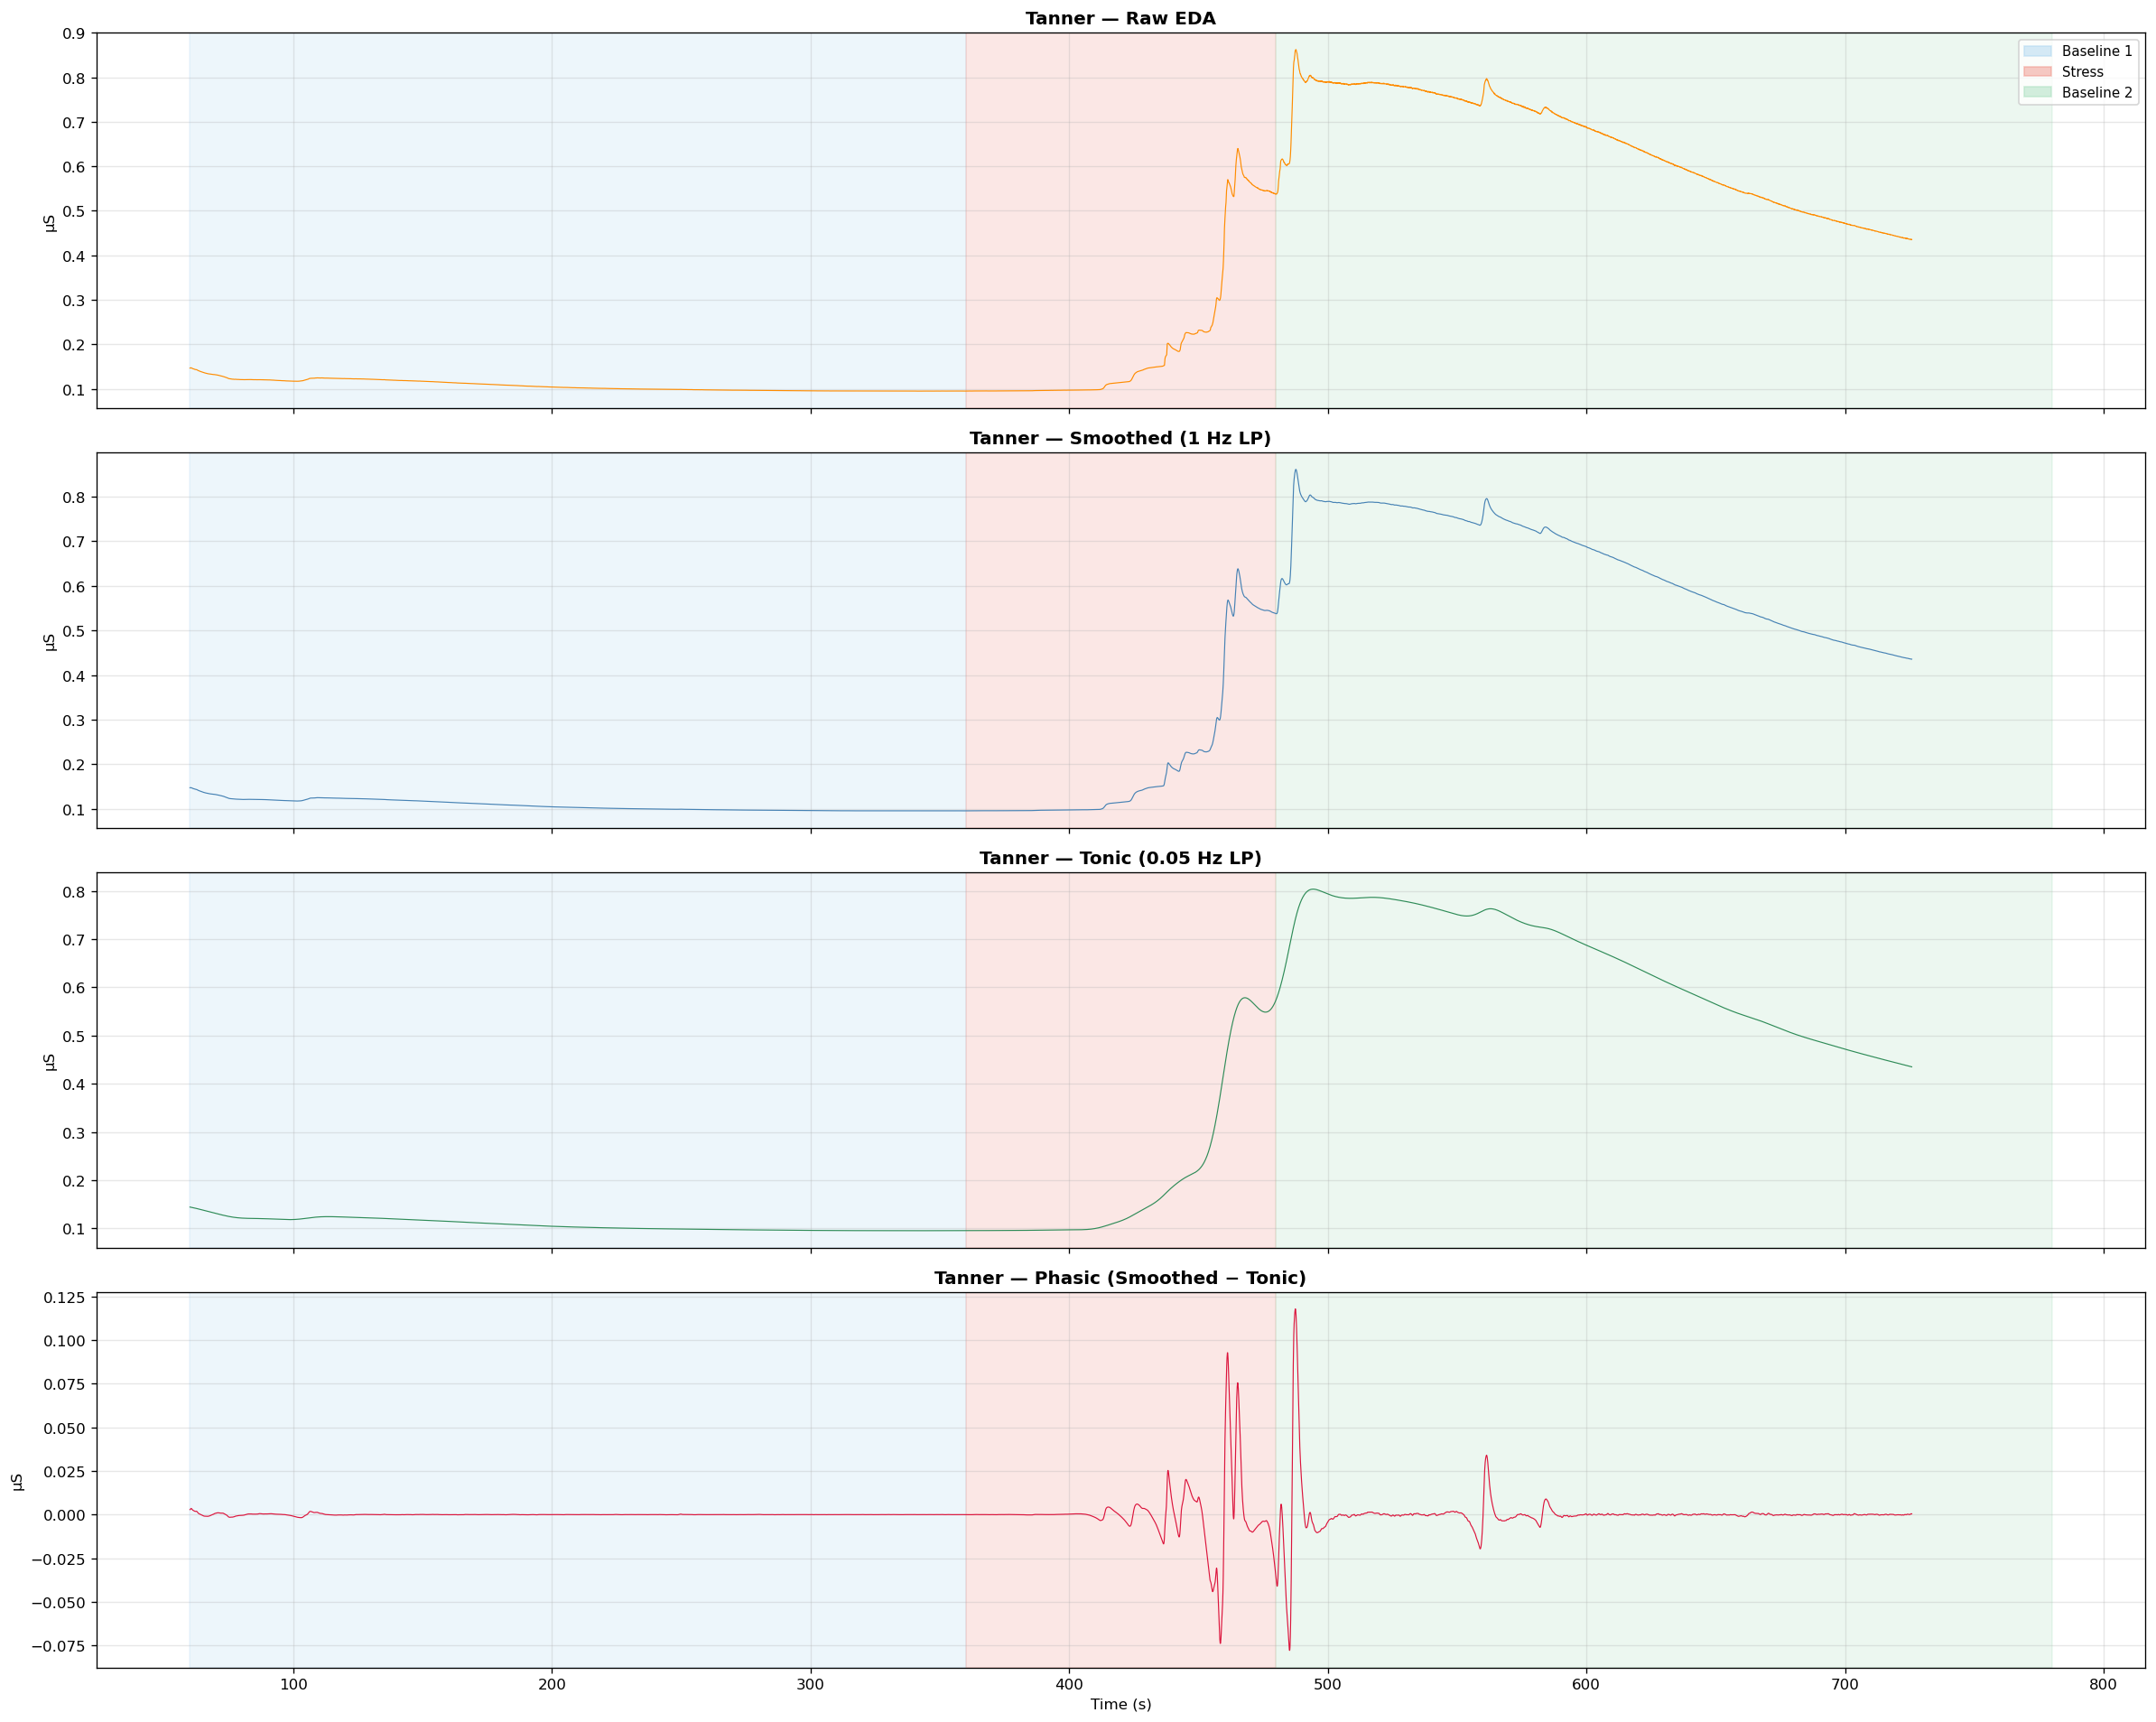

In [4]:
for name, d in data.items():
    t = d['eda_sec_t']

    fig, axes = plt.subplots(4, 1, figsize=(20, 16), sharex=True)
    titles  = ['Raw EDA', 'Smoothed (1 Hz LP)', 'Tonic (0.05 Hz LP)', 'Phasic (Smoothed − Tonic)']
    signals = [d['eda_raw_t'], d['eda_smooth_t'], d['eda_tonic_t'], d['eda_phasic_t']]
    colors  = ['darkorange', 'steelblue', 'seagreen', 'crimson']

    for ax, title, sig, c in zip(axes, titles, signals, colors):
        shade_phases(ax)
        ax.plot(t, sig, color=c, linewidth=0.7)
        ax.set_title(f'{name} — {title}', fontweight='bold')
        ax.set_ylabel('µS')
        ax.grid(True, alpha=0.3)

    phase_legend(axes[0])
    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()


## PPG Processing — Bandpass Filter & Heart Rate Extraction

Using the **PG (green LED) channel**. Green light is absorbed more strongly by hemoglobin than infrared, so motion-robust wrist PPG typically has a higher SNR on the green channel.

- **Bandpass** 0.5–4 Hz (2nd-order Butterworth, zero-phase) — isolates the cardiac band.
- **Peaks** via `scipy.signal.find_peaks` with min-distance = `0.33 * fs` (180 BPM max) and prominence = 30% of the filtered signal's std.
- **IBI** = diff of peak times, **HR_inst** = 60 / IBI. HR values outside [40, 180] BPM are rejected as implausible.

> **Note on sampling rate**: EmotiBit PG is 25 Hz. Peak-timing resolution is ~40 ms, giving ~1 BPM jitter at 60 BPM. Detected beats should align visually with systolic upstrokes — verify before trusting HRV metrics.

In [ ]:
for name, d in data.items():
    fs = d['fs_PG']
    nyq = fs / 2.0
    ppg_sec = d['PG_t']
    raw_ppg = d['PG_raw'].astype(float)

    # ── Bandpass 0.5–4 Hz (cardiac band) ────────────────────────────
    low, high = 0.5 / nyq, 4.0 / nyq
    b_bp, a_bp = butter(2, [low, high], btype='band')
    ppg_filt = filtfilt(b_bp, a_bp, raw_ppg)

    # ── Trim to analysis window ─────────────────────────────────────
    trim_mask = (ppg_sec >= TRIM_START) & (ppg_sec <= d['trim_end'])
    t = ppg_sec[trim_mask]
    raw_t = raw_ppg[trim_mask]
    filt_t = ppg_filt[trim_mask]

    # ── Peak detection ──────────────────────────────────────────────
    min_dist = max(1, int(0.33 * fs))
    peaks, _ = find_peaks(filt_t, distance=min_dist, prominence=np.std(filt_t) * 0.3)

    # ── IBI → instantaneous HR ──────────────────────────────────────
    peak_times = t[peaks]
    ibi = np.diff(peak_times)
    hr_inst = 60.0 / ibi
    hr_times = (peak_times[:-1] + peak_times[1:]) / 2

    valid = (hr_inst >= 40) & (hr_inst <= 180)
    hr_inst = hr_inst[valid]
    hr_times = hr_times[valid]

    d['ppg_sec_t']  = t
    d['ppg_raw_t']  = raw_t
    d['ppg_filt_t'] = filt_t
    d['ppg_peaks']  = peaks
    d['hr_times']   = hr_times
    d['hr_inst']    = hr_inst

    print(f'{name}: {len(peaks)} beats detected | mean HR = {hr_inst.mean():.1f} BPM | range = [{hr_inst.min():.0f}, {hr_inst.max():.0f}] BPM')
    print()


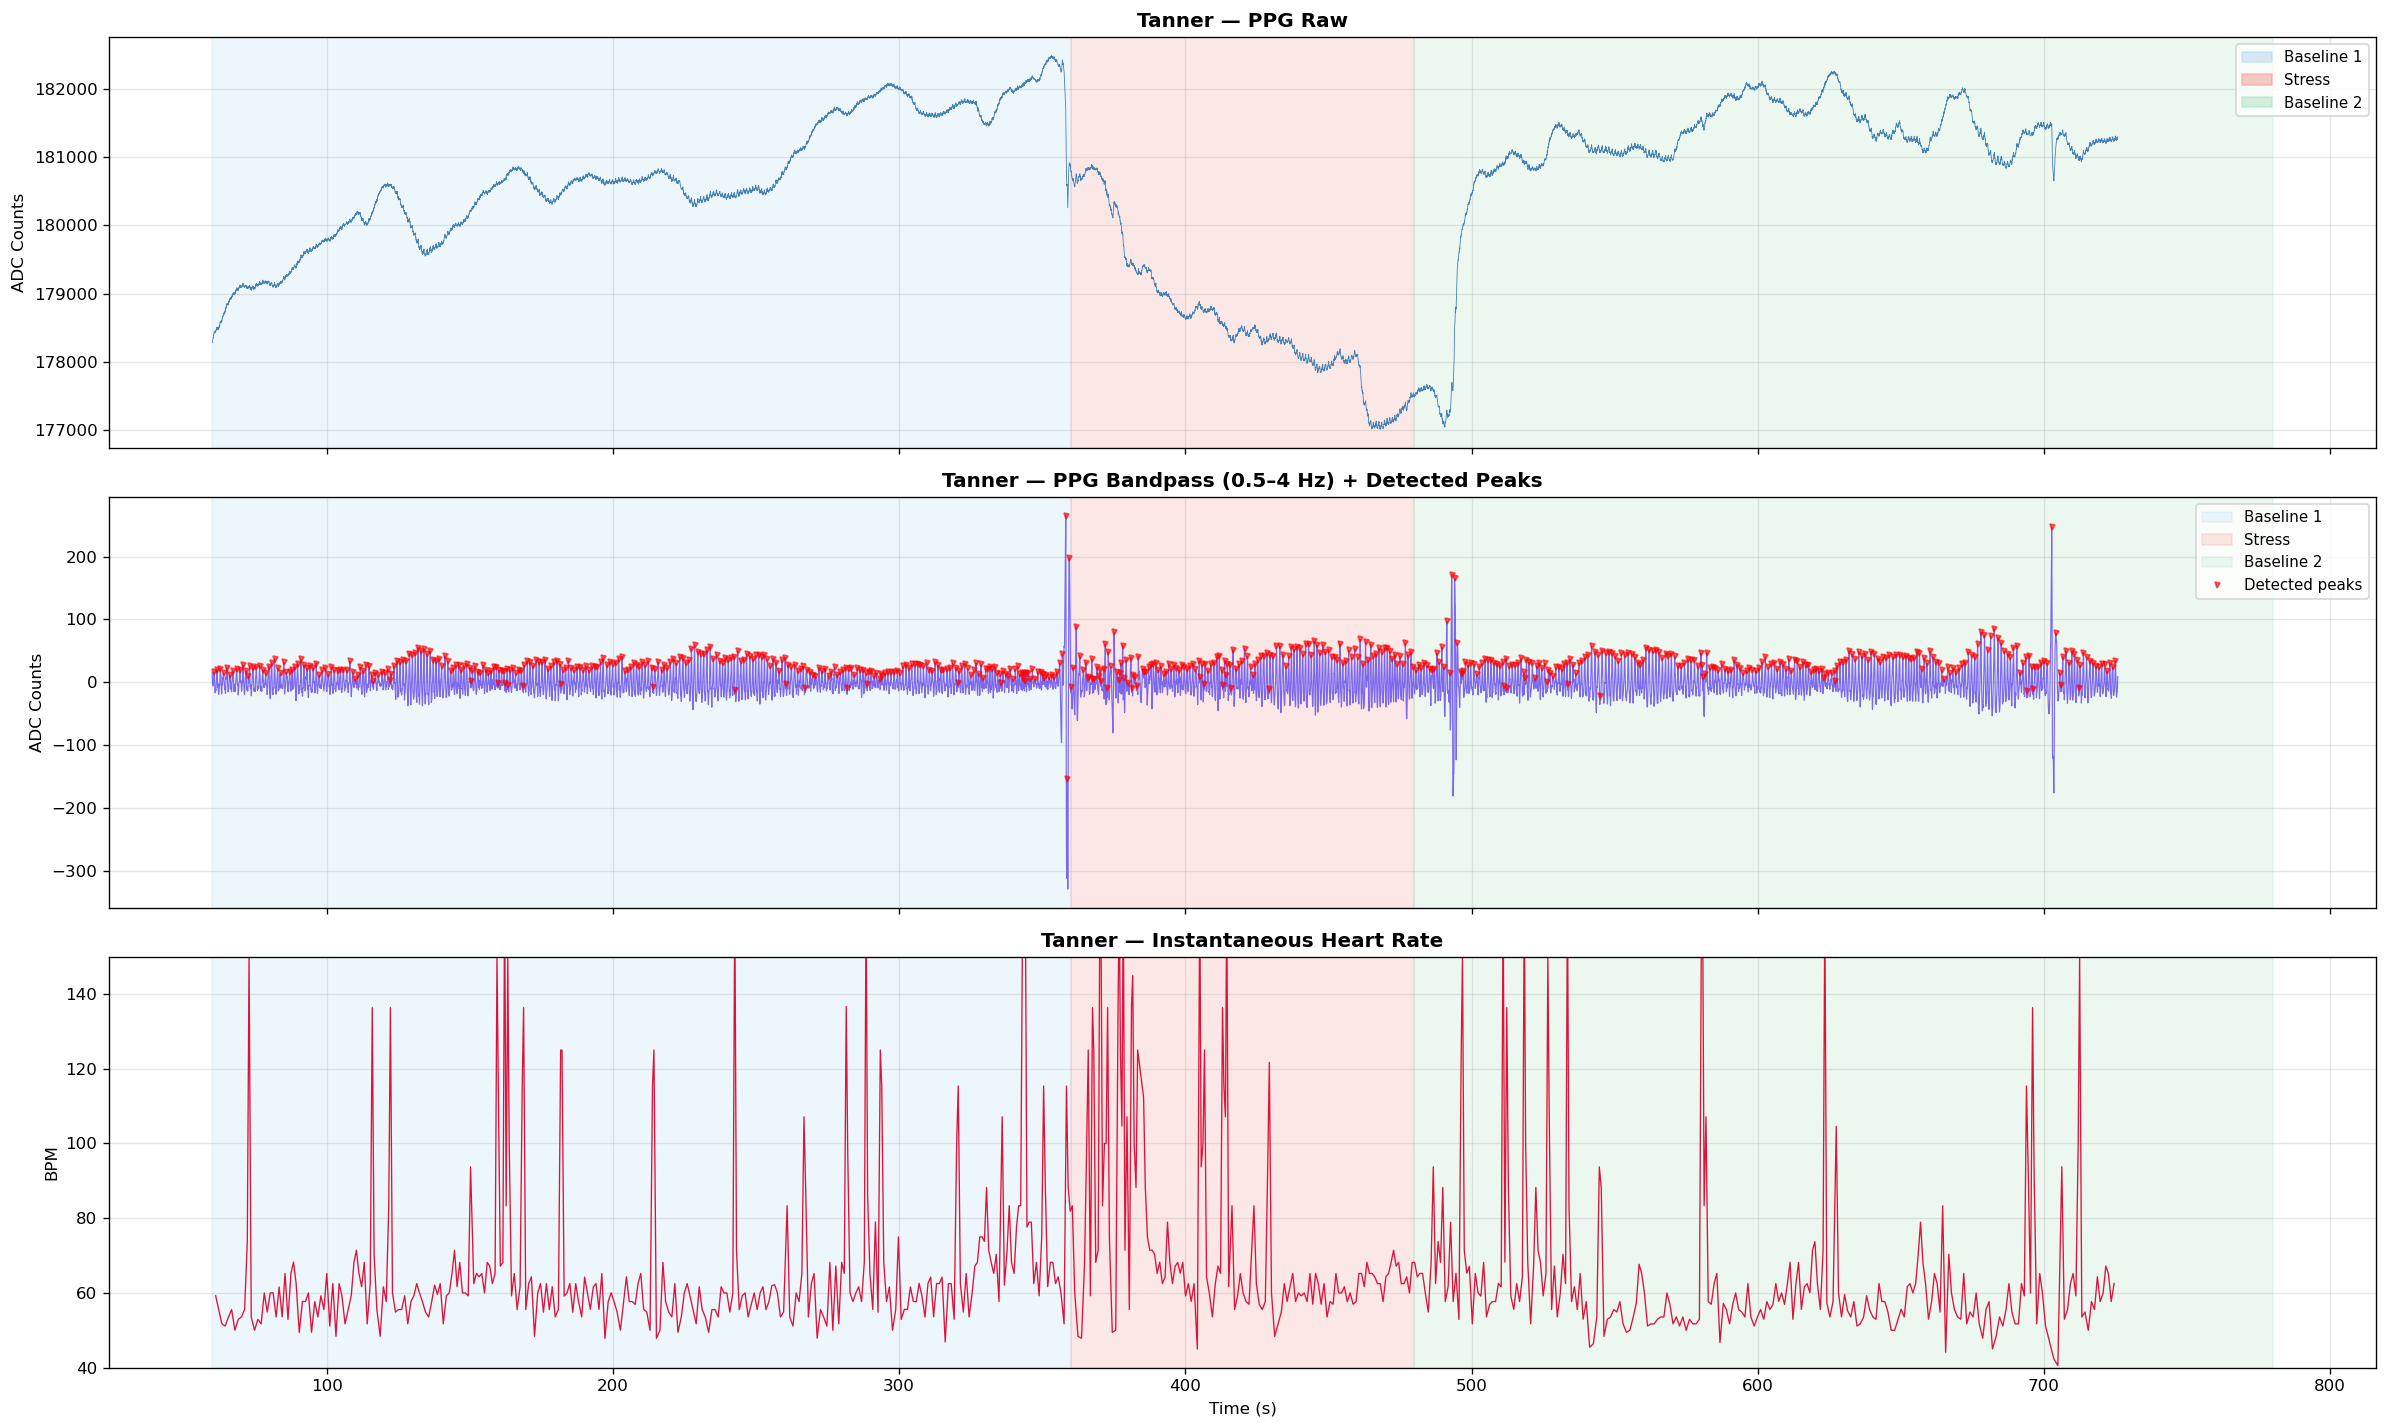

In [7]:
for name, d in data.items():
    t = d['ppg_sec_t']
    fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

    # Raw PPG
    shade_phases(axes[0])
    axes[0].plot(t, d['ppg_raw_t'], color='steelblue', linewidth=0.5)
    axes[0].set_title(f'{name} — PPG Raw', fontweight='bold')
    axes[0].set_ylabel('ADC Counts')
    axes[0].grid(True, alpha=0.3)
    phase_legend(axes[0])

    # Filtered + peaks
    shade_phases(axes[1])
    axes[1].plot(t, d['ppg_filt_t'], color='mediumslateblue', linewidth=0.7)
    axes[1].plot(t[d['ppg_peaks']], d['ppg_filt_t'][d['ppg_peaks']],
                 'rv', markersize=3, alpha=0.6, label='Detected peaks')
    axes[1].set_title(f'{name} — PPG Bandpass (0.5–4 Hz) + Detected Peaks', fontweight='bold')
    axes[1].set_ylabel('ADC Counts')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='upper right', fontsize=9)

    # Instantaneous HR
    shade_phases(axes[2])
    axes[2].plot(d['hr_times'], d['hr_inst'], color='crimson', linewidth=0.8)
    axes[2].set_title(f'{name} — Instantaneous Heart Rate', fontweight='bold')
    axes[2].set_ylabel('BPM')
    axes[2].set_xlabel('Time (s)')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim(40, 150)

    plt.tight_layout()
    plt.show()


## Skin Temperature (T1)

Wrist skin temperature can shift slightly during acute stress (peripheral vasoconstriction cools the periphery), but the wrist response is usually modest and slow. Included here as a secondary channel and as a sanity check that the sensor stayed in thermal contact with the skin.

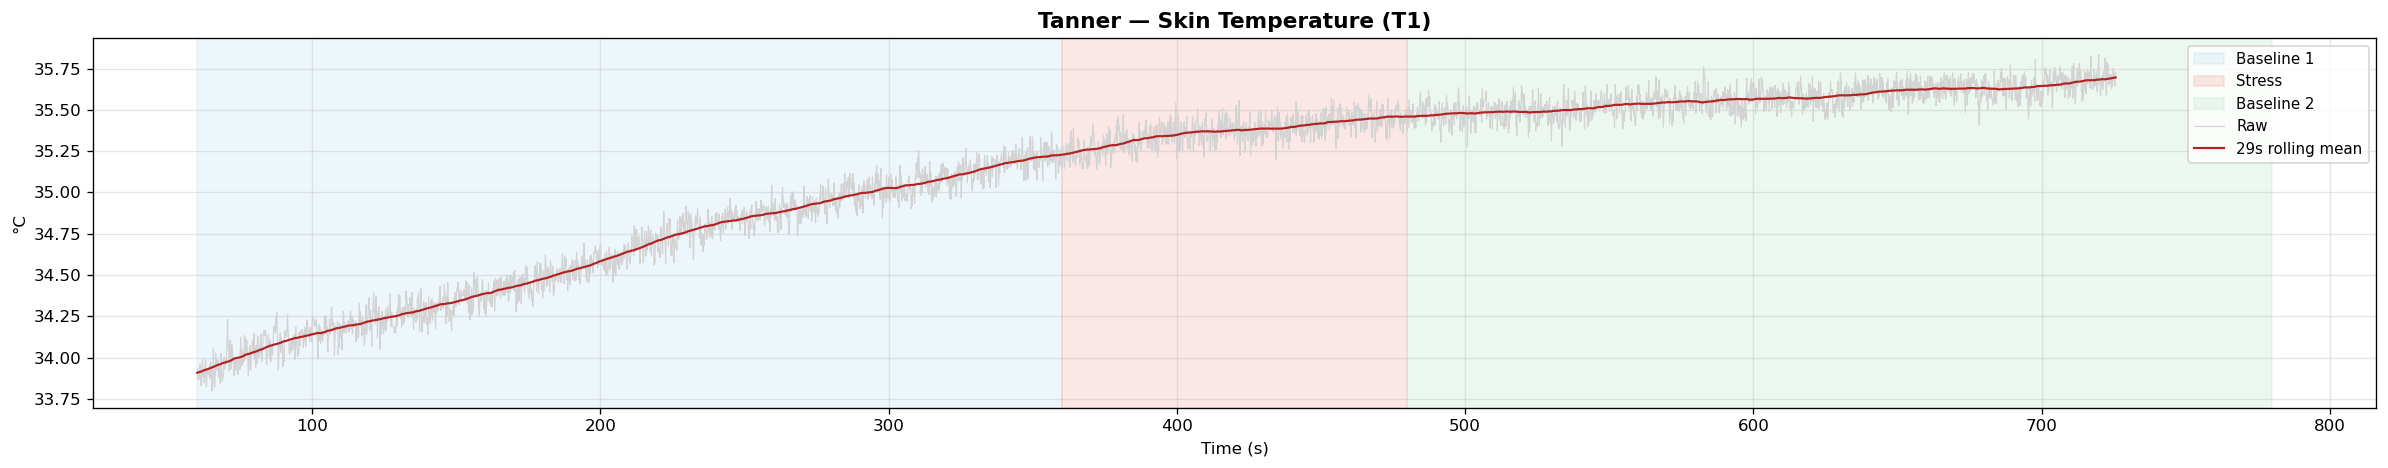

Tanner — mean T1 by phase:
  Baseline 1 : 34.623 °C  (n=2250)
  Stress     : 35.368 °C  (n=900)
  Baseline 2 : 35.567 °C  (n=1843)



In [8]:
for name, d in data.items():
    fs = d['fs_T1']
    t1_sec = d['T1_t']
    raw_t1 = d['T1_raw'].astype(float)

    # Light smoothing: ~30 s rolling mean (fs ≈ 7.5 Hz → ~225 samples)
    window = max(5, int(30 * fs))
    t1_smooth = pd.Series(raw_t1).rolling(window=window, min_periods=1, center=True).mean().values

    # Trim to analysis window
    trim_mask = (t1_sec >= TRIM_START) & (t1_sec <= d['trim_end'])
    d['t1_sec_t']    = t1_sec[trim_mask]
    d['t1_raw_t']    = raw_t1[trim_mask]
    d['t1_smooth_t'] = t1_smooth[trim_mask]

    # Plot
    fig, ax = plt.subplots(figsize=(20, 4))
    shade_phases(ax)
    ax.plot(d['t1_sec_t'], d['t1_raw_t'], color='lightgray', linewidth=0.7, label='Raw')
    ax.plot(d['t1_sec_t'], d['t1_smooth_t'], color='firebrick', linewidth=1.3, label=f'{int(window/fs)}s rolling mean')
    ax.set_title(f'{name} — Skin Temperature (T1)', fontsize=13, fontweight='bold')
    ax.set_ylabel('°C')
    ax.set_xlabel('Time (s)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

    # Per-phase mean
    print(f'{name} — mean T1 by phase:')
    for phase, (t0, t1) in PHASES_ABS.items():
        m = (d['t1_sec_t'] >= t0) & (d['t1_sec_t'] < t1)
        seg = d['t1_smooth_t'][m]
        if len(seg) > 0:
            print(f'  {phase:<11s}: {seg.mean():.3f} °C  (n={len(seg)})')
    print()


## Accelerometer — Motion-Artifact Sanity Check

Stroop is a seated, low-motion task. If the ACC magnitude std is low and uniform across phases, we can trust the EDA phasic bursts and HR shifts as physiological signals. If ACC spikes during the Stress phase, phasic EDA bursts and any HR artifacts in that window may be motion-induced and should be discounted.

- Magnitude: $|a| = \sqrt{AX^2 + AY^2 + AZ^2}$ — at rest this sits near 1 g (gravity).
- Per-phase `std` and the % of samples exceeding `mean + 3σ` (full-recording threshold) flag movement.

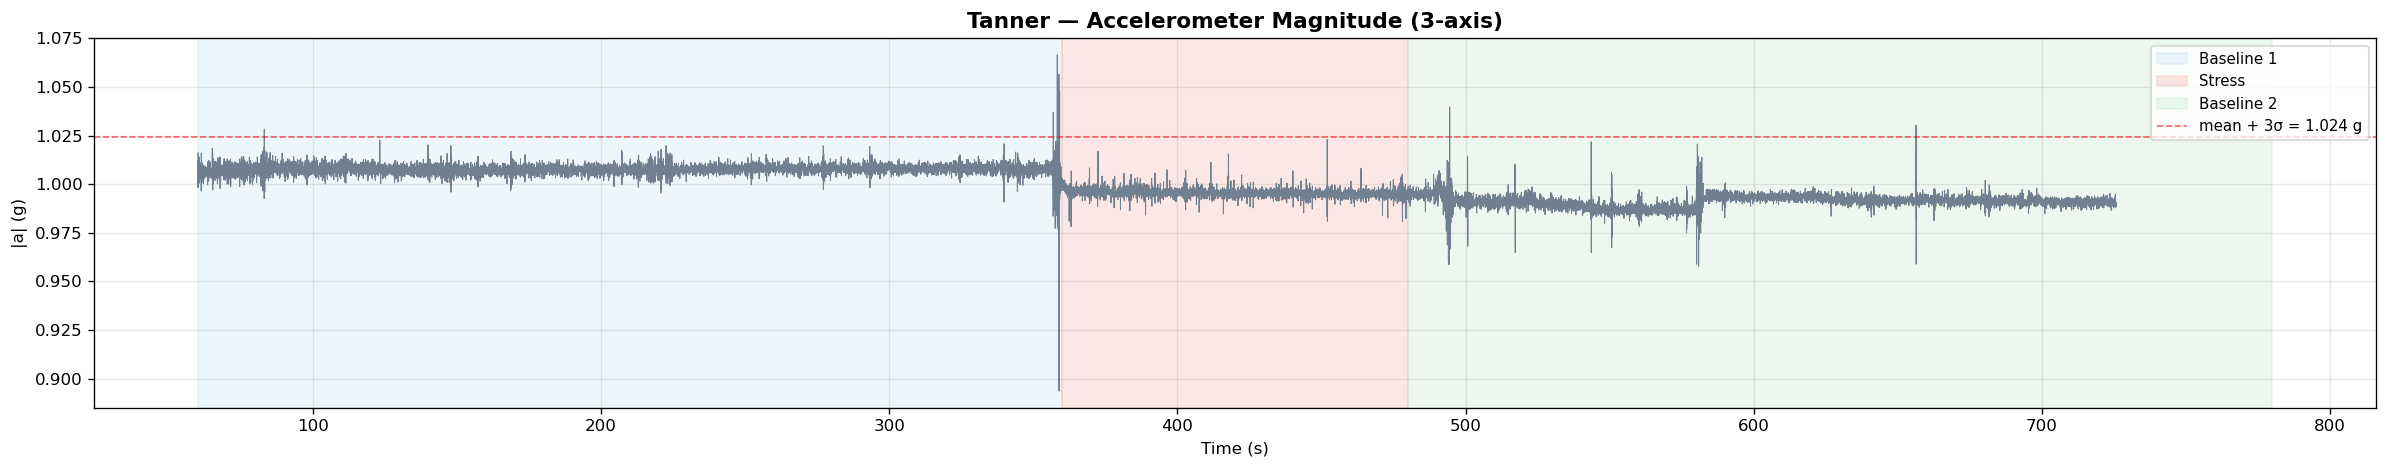

Tanner — motion by phase:
  Baseline 1 : mean=1.008 g  std=0.0033 g  >thresh=0.1%
  Stress     : mean=0.996 g  std=0.0026 g  >thresh=0.0%
  Baseline 2 : mean=0.991 g  std=0.0036 g  >thresh=0.0%



In [9]:
for name, d in data.items():
    # The three axes are logged on separate timestamp grids. Interpolate AY/AZ
    # onto the AX timeline so we can compute magnitude sample-by-sample.
    t_ax = d['AX_t']
    ax_v = d['AX_raw'].astype(float)
    ay_v = np.interp(t_ax, d['AY_t'], d['AY_raw'].astype(float))
    az_v = np.interp(t_ax, d['AZ_t'], d['AZ_raw'].astype(float))
    mag = np.sqrt(ax_v ** 2 + ay_v ** 2 + az_v ** 2)

    # Trim
    trim_mask = (t_ax >= TRIM_START) & (t_ax <= d['trim_end'])
    t_acc = t_ax[trim_mask]
    mag_t = mag[trim_mask]

    d['acc_sec_t'] = t_acc
    d['acc_mag_t'] = mag_t

    # Motion threshold: mean + 3σ of the full analysis window
    thresh = mag_t.mean() + 3 * mag_t.std()

    fig, ax = plt.subplots(figsize=(20, 4))
    shade_phases(ax)
    ax.plot(t_acc, mag_t, color='slategray', linewidth=0.6)
    ax.axhline(thresh, color='red', linewidth=1.0, linestyle='--', alpha=0.6, label=f'mean + 3σ = {thresh:.3f} g')
    ax.set_title(f'{name} — Accelerometer Magnitude (3-axis)', fontsize=13, fontweight='bold')
    ax.set_ylabel('|a| (g)')
    ax.set_xlabel('Time (s)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

    # Per-phase motion summary
    print(f'{name} — motion by phase:')
    for phase, (t0, t1) in PHASES_ABS.items():
        m = (t_acc >= t0) & (t_acc < t1)
        seg = mag_t[m]
        if len(seg) > 0:
            pct_over = (seg > thresh).mean() * 100
            print(f'  {phase:<11s}: mean={seg.mean():.3f} g  std={seg.std():.4f} g  >thresh={pct_over:.1f}%')
    print()


## Phase-Level Feature Extraction & Comparison

For each phase (Baseline 1, Stress, Baseline 2):

| Feature | Meaning |
|---|---|
| **EDA Tonic Mean (µS)** | skin conductance level — sympathetic tone |
| **EDA Phasic Std (µS)** | variability of SCR bursts — sympathetic reactivity |
| **Mean HR (BPM)** | average heart rate |
| **HR Std (BPM)** | beat-rate variability (time-domain) |
| **RMSSD (ms)** | root mean square of successive IBI differences — parasympathetic indicator |
| **T1 Mean (°C)** | wrist skin temperature |
| **ACC Std (g)** | motion activity (artifact flag) |

In [10]:
rows = []

for name, d in data.items():
    for phase, (t0, t1) in PHASES_ABS.items():
        # EDA
        m_eda = (d['eda_sec_t'] >= t0) & (d['eda_sec_t'] < t1)
        tonic_seg  = d['eda_tonic_t'][m_eda]
        phasic_seg = d['eda_phasic_t'][m_eda]
        eda_tonic_mean = tonic_seg.mean()  if len(tonic_seg)  > 0 else np.nan
        eda_phasic_std = phasic_seg.std()  if len(phasic_seg) > 0 else np.nan

        # HR (from instantaneous HR)
        m_hr = (d['hr_times'] >= t0) & (d['hr_times'] < t1)
        hr_seg = d['hr_inst'][m_hr]
        hr_mean = hr_seg.mean() if len(hr_seg) > 0 else np.nan
        hr_std  = hr_seg.std()  if len(hr_seg) > 0 else np.nan

        # RMSSD from IBIs inside the phase
        peak_times_all = d['ppg_sec_t'][d['ppg_peaks']]
        m_pt = (peak_times_all >= t0) & (peak_times_all < t1)
        pt_seg = peak_times_all[m_pt]
        if len(pt_seg) > 2:
            ibi_seg = np.diff(pt_seg) * 1000.0  # ms
            rmssd = float(np.sqrt(np.mean(np.diff(ibi_seg) ** 2)))
        else:
            rmssd = np.nan

        # T1
        m_t1 = (d['t1_sec_t'] >= t0) & (d['t1_sec_t'] < t1)
        t1_seg = d['t1_smooth_t'][m_t1]
        t1_mean = t1_seg.mean() if len(t1_seg) > 0 else np.nan

        # ACC std
        m_acc = (d['acc_sec_t'] >= t0) & (d['acc_sec_t'] < t1)
        acc_seg = d['acc_mag_t'][m_acc]
        acc_std = acc_seg.std() if len(acc_seg) > 0 else np.nan

        rows.append({
            'Subject': name,
            'Phase': phase,
            'EDA Tonic Mean (µS)': eda_tonic_mean,
            'EDA Phasic Std (µS)': eda_phasic_std,
            'Mean HR (BPM)': hr_mean,
            'HR Std (BPM)': hr_std,
            'RMSSD (ms)': rmssd,
            'T1 Mean (°C)': t1_mean,
            'ACC Std (g)': acc_std,
        })

features_df = pd.DataFrame(rows)
features_df.style.format(precision=3).set_caption('Phase-Level Features')


,Subject,Phase,EDA Tonic Mean (µS),EDA Phasic Std (µS),Mean HR (BPM),HR Std (BPM),RMSSD (ms),T1 Mean (°C),ACC Std (g)
0,Tanner,Baseline 1,0.108,0.000,67.393,22.812,223.795,34.623,0.003
1,Tanner,Stress,0.207,0.018,77.206,29.410,264.408,35.368,0.003
2,Tanner,Baseline 2,0.647,0.013,65.422,23.260,235.896,35.567,0.004


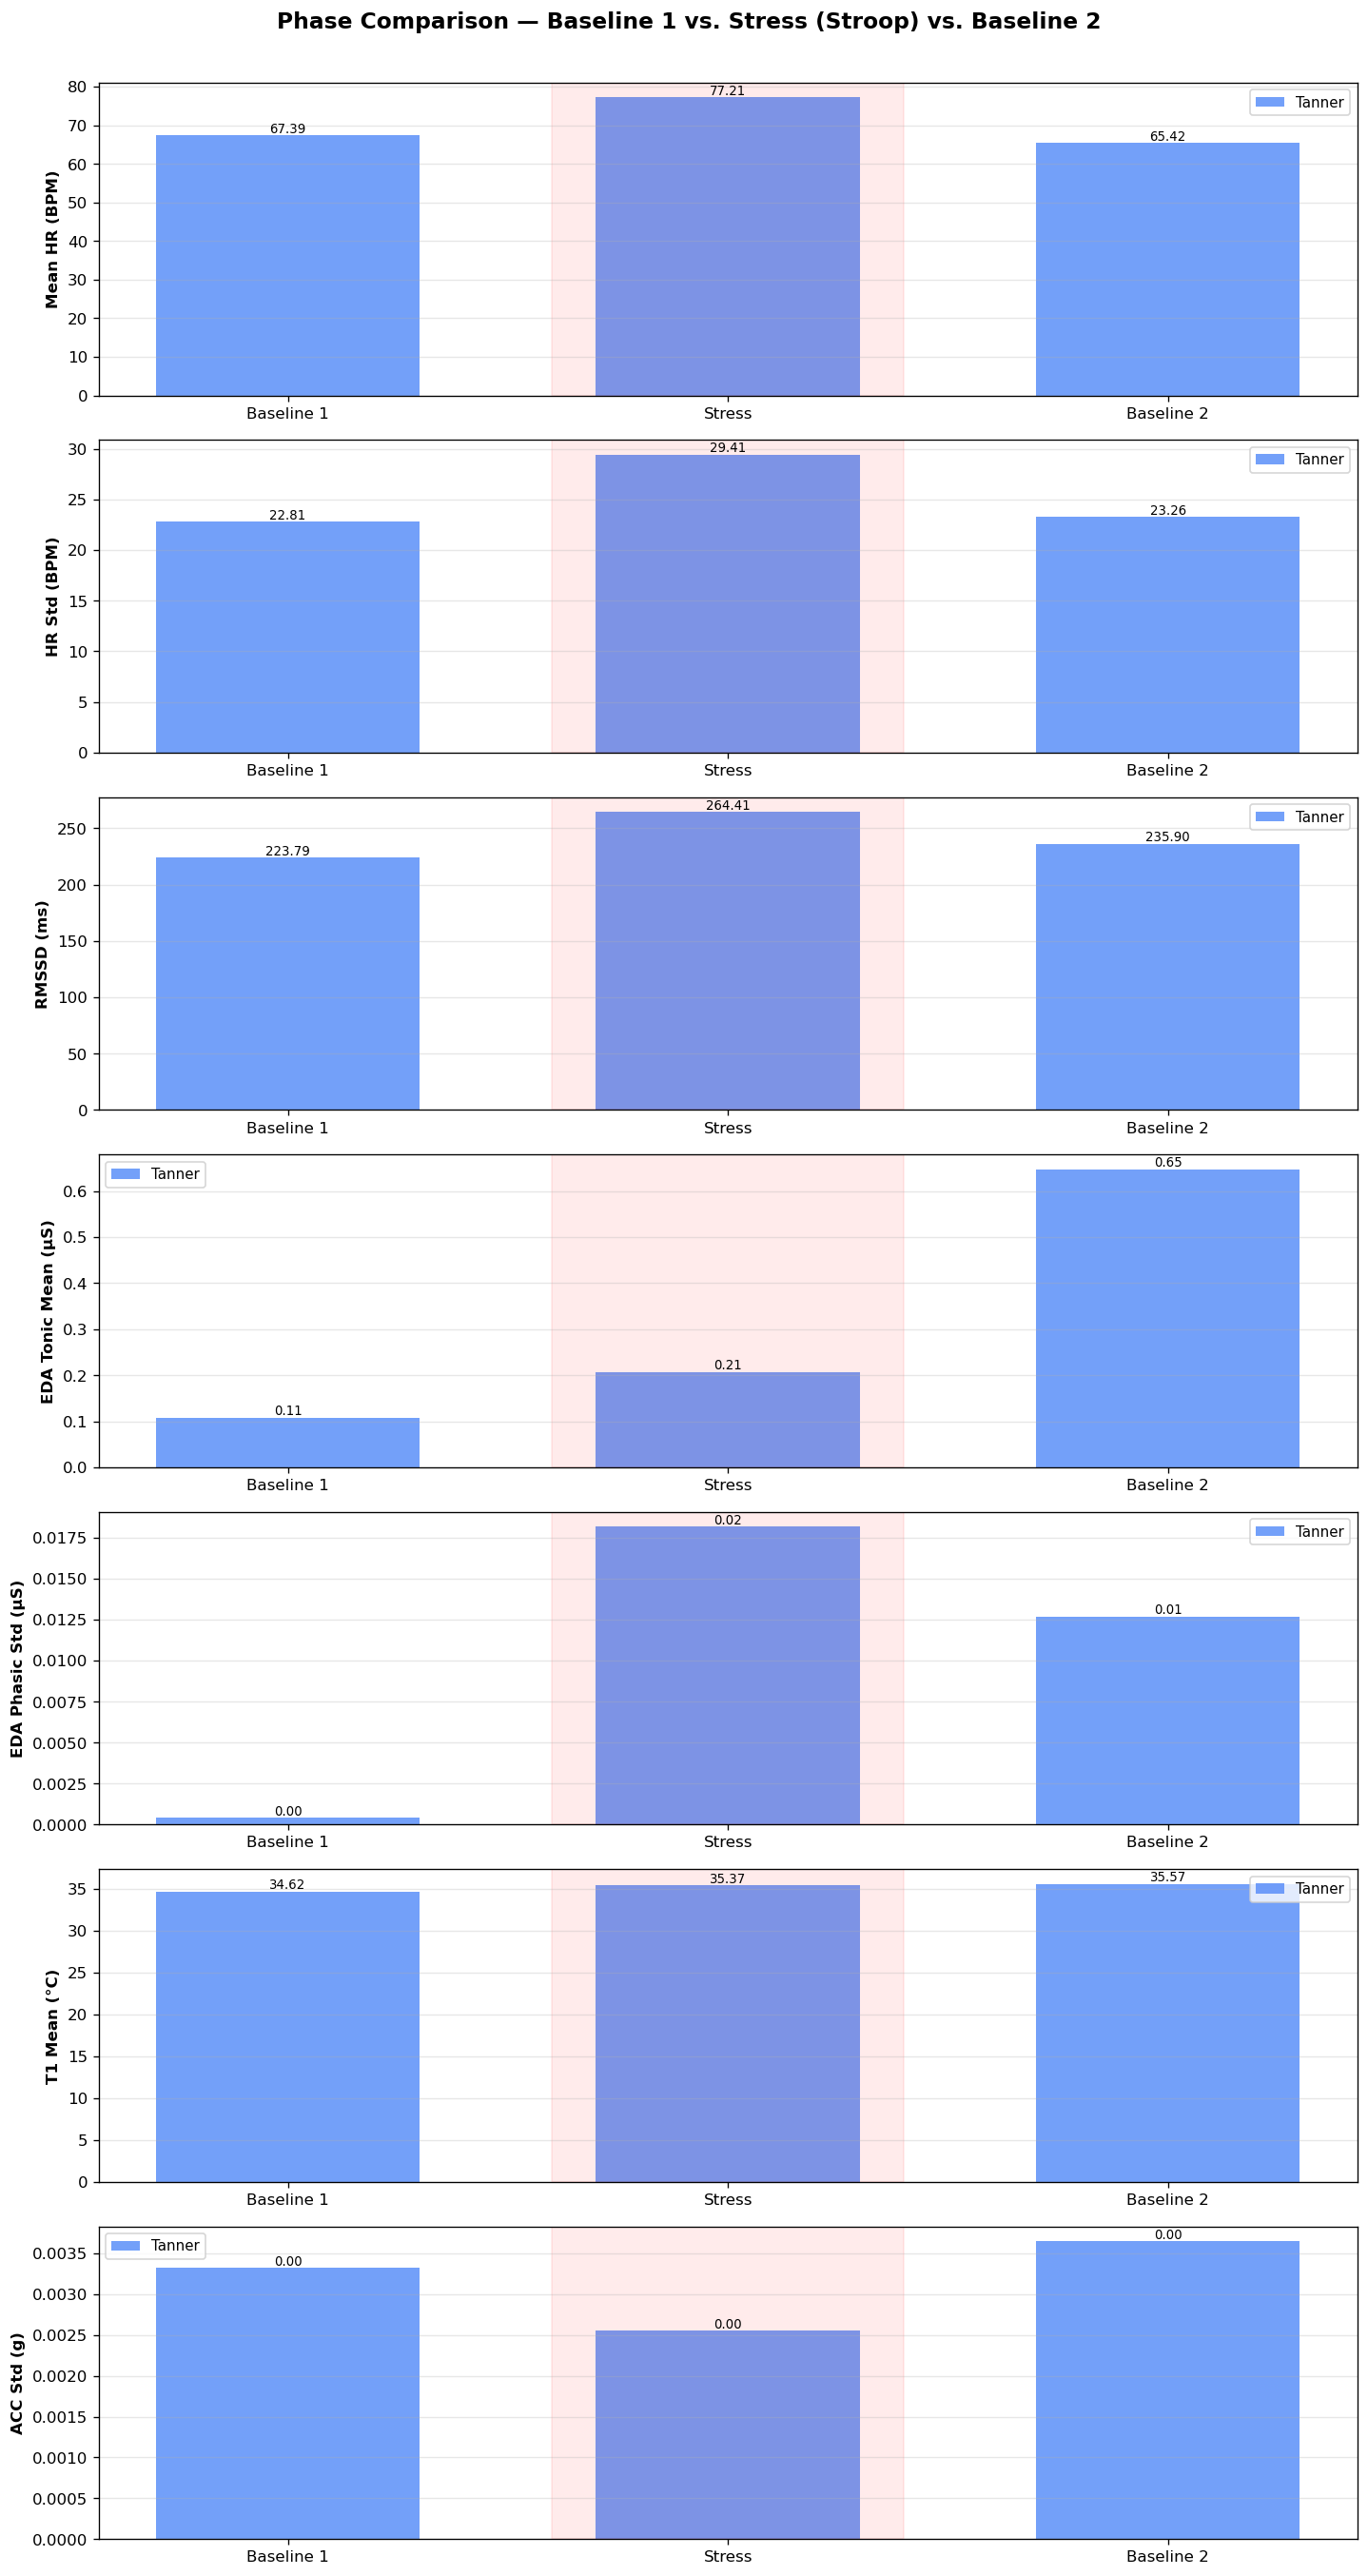

In [11]:
metrics = [
    'Mean HR (BPM)',
    'HR Std (BPM)',
    'RMSSD (ms)',
    'EDA Tonic Mean (µS)',
    'EDA Phasic Std (µS)',
    'T1 Mean (°C)',
    'ACC Std (g)',
]
subjects = list(data.keys())
phases = list(PHASES_ABS.keys())

fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 3.2 * len(metrics)))
bar_width = 0.6 if len(subjects) == 1 else 0.25
x = np.arange(len(phases))
subj_palette = ['#5B8FF9', '#D2B4DE', '#F4A261']

for ax, metric in zip(axes, metrics):
    for i, subj in enumerate(subjects):
        vals = features_df[features_df['Subject'] == subj].set_index('Phase').loc[phases, metric].values
        offset = 0 if len(subjects) == 1 else i * bar_width
        bars = ax.bar(x + offset, vals, bar_width, label=subj,
                      color=subj_palette[i % len(subj_palette)], alpha=0.85)
        for bar, v in zip(bars, vals):
            if np.isfinite(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        f'{v:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_ylabel(metric, fontweight='bold')
    if len(subjects) == 1:
        ax.set_xticks(x)
    else:
        ax.set_xticks(x + bar_width * (len(subjects) - 1) / 2)
    ax.set_xticklabels(phases)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Highlight the Stress phase background
    stress_idx = phases.index('Stress')
    span_w = bar_width * len(subjects) if len(subjects) > 1 else bar_width
    ax.axvspan(stress_idx - 0.4, stress_idx + span_w - 0.2,
               alpha=0.08, color='red')

fig.suptitle('Phase Comparison — Baseline 1 vs. Stress (Stroop) vs. Baseline 2',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()


## What to Look For

**Expected stress responses during the Stroop block (minutes 6–8):**
- **HR increase** — sympathetic activation raises heart rate during cognitive conflict
- **RMSSD decrease** — reduced parasympathetic tone lowers beat-to-beat variability
- **EDA tonic rise** — skin conductance level creeps up with sympathetic arousal
- **EDA phasic bursts** — more frequent / larger SCRs during Stroop trials
- **Skin temp (T1)** — often only slight change at the wrist; ambiguous
- **ACC** — should stay low (seated task); movement would invalidate the other signals

**Recovery (minutes 8–13, Baseline 2):**
- Signals should drift back toward Baseline 1 levels.
- RMSSD typically recovers within minutes; tonic EDA can remain elevated.

**Hardware validation checks:**
- Detected PPG peaks align visually with systolic upstrokes (no missed/doubled beats).
- EDA stays in a physiologically plausible range (~0.05 – 50 µS) after artifact removal.
- Sampling rates are stable and match nominal (EA ≈ 15 Hz, PI ≈ 25 Hz, T1 ≈ 7.5 Hz, ACC ≈ 25 Hz).
- No large ACC spikes during the Stress window — otherwise flag EDA/HR shifts as possibly motion-driven.

**If the expected pattern does not appear**, cross-check: (1) Was Stroop actually hard enough to induce stress? (2) Did motion or talking contaminate the window? (3) Is the PPG SNR high enough at 25 Hz to resolve HRV reliably (RMSSD is especially sensitive to sample-rate jitter at 25 Hz)?